Algoritmos Genéticos y Optimización Heurística - UTN-FRT
# **Trabajo Práctico N°6**
##**Tema**: Aplicaciones de AG - Tachos##

Integrantes:

Carlino Luciano - 53148

Di Pietro Luciano - 53197

## Ejercicio 1
Se tiene el siguiente modelo simplificado del funcionamiento de un sector de una fábrica de azúcar: Se tienen **N** tachos de cocimiento, cada uno de los cuales consume vapor de una determinada manera a lo largo del tiempo. El consumo total de vapor puede calcularse como la suma del consumo de vapor individual de cada tacho. El tiempo entre que empieza a consumir el primer tacho hasta que deja de consumir el último tacho es **tMAX** (llamado tiempo total del ciclo o *timespan*). Durante este tiempo, el consumo de vapor varía en el tiempo, consumiendo mayor energía mientras mayor sea esta variación. Este problema consiste en reducir la energía que se consume por la variación de vapor a lo largo del ciclo de cocimiento de la azúcar. A continuación se brindan detalles del modelado del problema:


Un tacho de cocimiento consume vapor durante un lapso de tiempo. El proceso arranca en el tiempo t0, y finaliza en t1 = t0+1 donde ya se consumió todo el vapor del tacho. Es decir, el proceso dura *una unidad de tiempo*. Este comportamiento se puede modelar como una parábola con las ramas hacia abajo, donde alcanza su máximo en t = 1, y está definida en el intervalo  t0 ≤ t ≤ t0+1, siendo nulo fuera de dicho intervalo. Es decir:

  * VaporTacho_i(t) = **0**, *si 0 ≤ t ≤ t0*
  * VaporTacho_i(t) = **1 - (2 * t0 - 2t + 1)^2**, *si t0 ≤ t ≤ t0+1*
  * VaporTacho_i(t) = **0**, *si t1 ≤ t ≤ tMAX*








Consumo de vapor para un tacho, tomando como ejemplo t0 = 1.000000


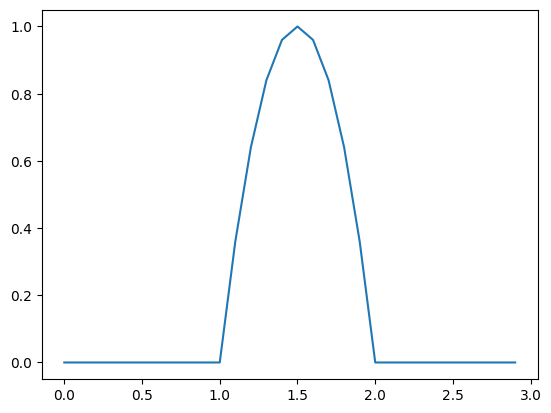

In [24]:
def VaporTacho_i(t, t0):
  return 1 - (2*t0-2*t + 1)**2 if t > t0 and t < t0 + 1 else 0

import matplotlib.pyplot as plt
t0 = 1
intervalo = [x/10 for x in range(30)]
vt = [VaporTacho_i(t,t0) for t in intervalo]
plt.figure()
plt.plot(intervalo, vt)
print('Consumo de vapor para un tacho, tomando como ejemplo t0 = %f'%t0)

Ahora suponga que la fábrica cuenta con una cantidad de tachos de cocimiento **N** que puede variar entre 5 y 20. Los tachos arrancan de manera
independiente entre ellos, y el vapor total puede ser calculado en cada instante de tiempo sumando el vapor producido por cada tacho. Es decir:

* VaporTotal(t) = SUM_i { VaporTacho_i(t) }

Consumo de vapor total con dos tachos, tomando como ejemplo t0 = 0.800000 y t0=1.100000


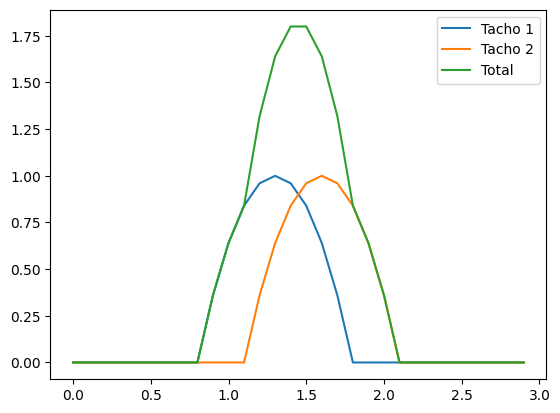

In [13]:
def VaporTotal(t_inicios, intervalo):
  return [sum([VaporTacho_i(t,t0) for t0 in t_inicios]) for t in intervalo]

t0_1 = 0.8
t0_2 = 1.1
vt1 = [VaporTacho_i(t, t0_1) for t in intervalo]
vt2 = [VaporTacho_i(t, t0_2) for t in intervalo]
plt.plot(intervalo, vt1, label='Tacho 1');
plt.plot(intervalo, vt2, label='Tacho 2');
vtotal = VaporTotal([t0_1, t0_2], intervalo)
plt.plot(intervalo, vtotal, label='Total');
plt.legend()
print('Consumo de vapor total con dos tachos, tomando como ejemplo t0 = %f y t0=%f'%(t0_1,t0_2))

El objetivo del problema es diseñar un Algoritmo Genético que organice el cronograma de arranques (*Schedule*) de los tachos, de manera que:
* Todos los tachos deben completar su ciclo.
* Se estabilizce el consumo de vapor total (que no existan grandes variaciones de vapor durante todo el proceso). Es decir, se prefieren soluciones que produzcan un consumo de vapor "*constante*".
* Se prefieren soluciones que brinden un tiempo total de funcionamiento menor.
* Se debe evitar la convergencia hacia las soluciones triviales e incorrectas:
* El algoritmo debe ser general, funcionando para diferente cantidad de tachos **N**.
  * Donde el tiempo total es mínimo debido a que todos los tachos arrancan juntos.
  * Los tachos arrancan uno despues de otro (no se superponen).



Soluciones triviales a evitar:


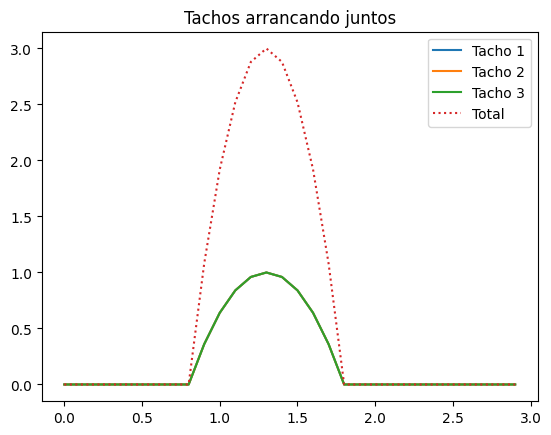

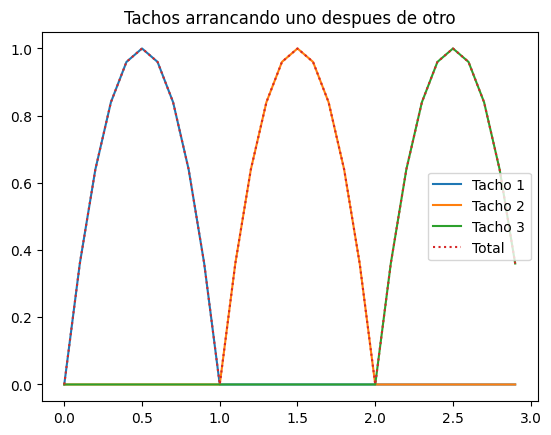

In [14]:
t0_1 = 0.8
t0_2 = 0.8
t0_3 = 0.8
vt1 = [VaporTacho_i(t, t0_1) for t in intervalo]
vt2 = [VaporTacho_i(t, t0_2) for t in intervalo]
vt3 = [VaporTacho_i(t, t0_3) for t in intervalo]
vtotal = VaporTotal([t0_1, t0_2, t0_3], intervalo)
plt.plot(intervalo, vt1, label='Tacho 1');
plt.plot(intervalo, vt2, label='Tacho 2');
plt.plot(intervalo, vt3, label='Tacho 3');
plt.plot(intervalo, vtotal, label='Total', linestyle=':');
plt.legend()
plt.title('Tachos arrancando juntos')

t0_1 = 0
t0_2 = 1
t0_3 = 2
vt1 = [VaporTacho_i(t, t0_1) for t in intervalo]
vt2 = [VaporTacho_i(t, t0_2) for t in intervalo]
vt3 = [VaporTacho_i(t, t0_3) for t in intervalo]
vtotal = VaporTotal([t0_1, t0_2, t0_3], intervalo)
plt.figure()
plt.plot(intervalo, vt1, label='Tacho 1');
plt.plot(intervalo, vt2, label='Tacho 2');
plt.plot(intervalo, vt3, label='Tacho 3');
plt.plot(intervalo, vtotal, label='Total', linestyle=':');
plt.legend()
plt.title('Tachos arrancando uno despues de otro')
print("Soluciones triviales a evitar:")

La función fitness, entonces, deberá tener en cuenta las variaciones de vapor total en el tiempo, y el tiempo total del ciclo.


Se pide:
1. Determinar una codificación adecuada (forma de representar las soluciones  para el problema).
2. Definir las restricciones para los valores en la solución (determinar la matriz de *Bounds*).
3. En base a la codificación elegida, definir una función *Fitness* que permita encontrar buenas soluciones en base a los objetivos del problema.
4. Determinar una arquitectura de algoritmos genéticos adecuada para resolver el problema:
  * Definir que tipo de algoritmo genético utilizar.
  * Elegir los operadores genéticos a utilizar.
5. Ajustar los parámetros adecuadamentes usando los criterios utilizados en los prácticos anteriores. La cantidad de generaciones y tamaño de la población pueden variar al tomar diferentes cantidad de tachos presentes.

In [15]:
def graficarResultadosTachos(solucion, tachos, intervalo):

    plt.figure()

    for i in range(len(solucion)):
        vt = [VaporTacho_i(t,solucion[i]) for t in intervalo]
        plt.plot(intervalo, vt, label=f'Tacho {i}')

    vtotal = VaporTotal(solucion, intervalo)
    equilibrio = Promedio(vtotal, intervalo, solucion)
    picos = Picos(vtotal, intervalo)
    variabilidad = Variabilidad(vtotal, intervalo, solucion)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.figure()
    plt.plot(intervalo, vtotal, label='Total', color='black', linestyle=':')
    for i in range(len(picos)):
        if picos[i] > 0:
            plt.plot(intervalo[i], picos[i], marker='+', color='red', linestyle='')
    plt.axhline(equilibrio, color='blue', linestyle='--', linewidth=1.2,
                label=f'Equilibrio ({equilibrio:.2f})')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.figure()
    plt.plot(intervalo, variabilidad, label='Varianza')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.show()

# **Solucion objetivo**
Comenzamos planteando una solución ideal, el optimo global, al cual llegamos manualmente por aproximación de la separacion del tiempo de inicio de cada tacho. Buscamos hacer esto para contar con un objetivo al momento de evaluar las curvas resultantes de nuestro genético.
Para definir esta situación ideal, donde la variabilidad de la curva sea minima y el tiempo total también, llegamos a dos posibles soluciones:

Solucion: [0.0, 0.707, 1.414, 2.121, 2.828, 3.5349999999999997, 4.242, 4.949, 5.656, 6.3629999999999995, 7.069999999999999, 7.776999999999999, 8.484, 9.190999999999999, 9.898, 10.604999999999999, 11.312, 12.019, 12.725999999999999, 13.433]


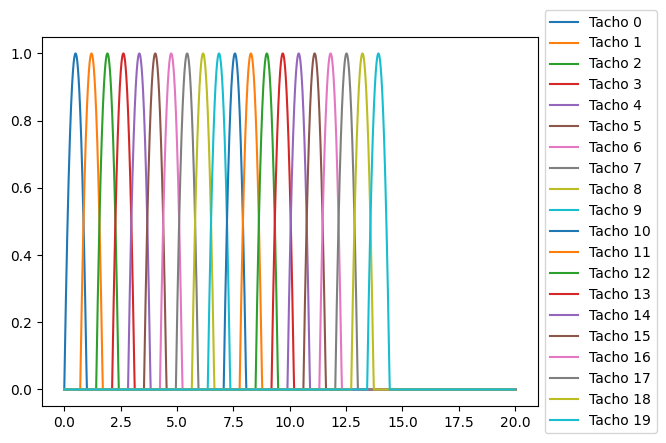

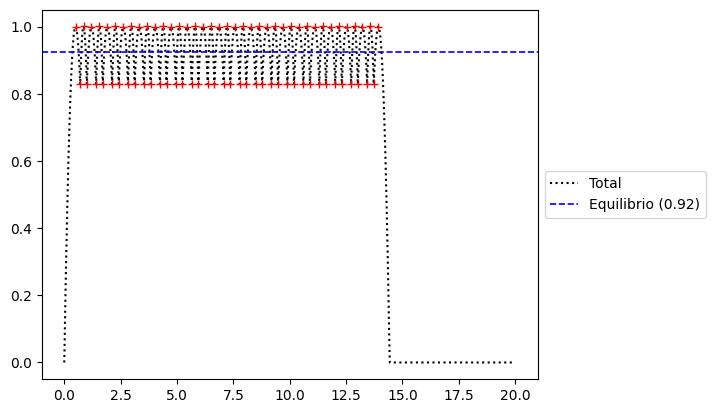

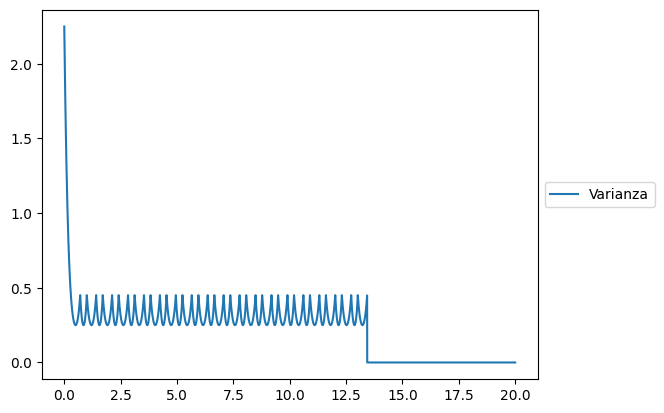

In [16]:
espaciado = 0.707
best_sol = []
tachos = 20
intervalo = [x/1000 for x in range(tachos*1000)]
for i in range(tachos):
    best_sol.append(espaciado * i)
print(f'Solucion: {best_sol}')
graficarResultadosTachos(best_sol, tachos, intervalo)

En esta solución se ve el valor maximo del vapor total cerca del valor máximo de cada tacho, con un equilibrio en 0.92 y variando entre 0.8 y 1, lo cual da una variacion porcentual del 21%

Solucion: [0.0, 0.408, 0.816, 1.224, 1.632, 2.04, 2.448, 2.856, 3.264, 3.6719999999999997, 4.08, 4.4879999999999995, 4.896, 5.303999999999999, 5.712, 6.119999999999999, 6.528, 6.936, 7.343999999999999, 7.752]


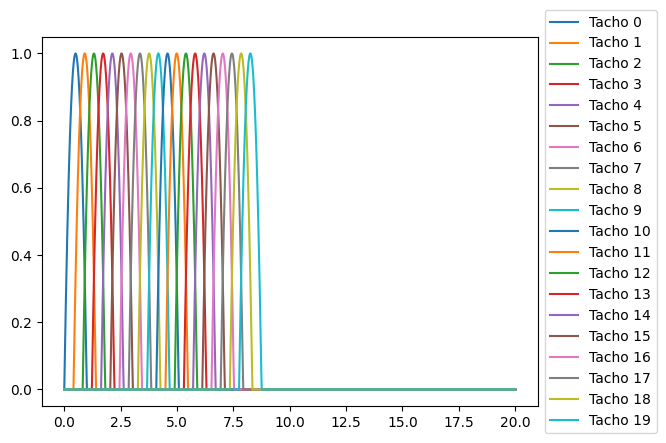

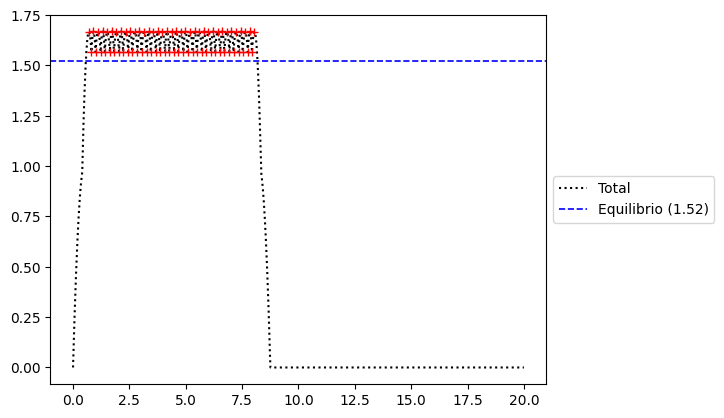

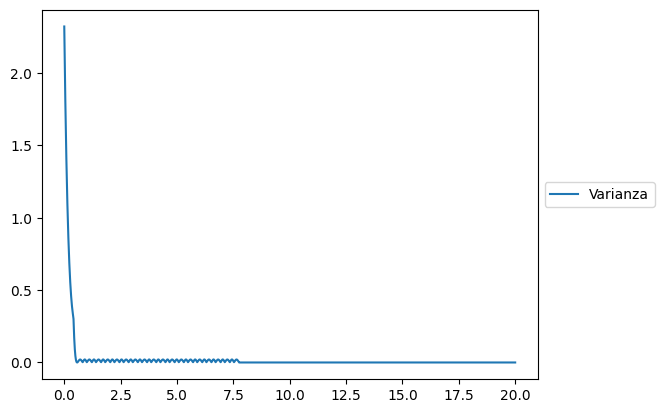

In [17]:
espaciado = 0.408
best_sol = []
tachos = 20
intervalo = [x/1000 for x in range(tachos*1000)]
for i in range(tachos):
    best_sol.append(espaciado * i)
print(f'Solucion: {best_sol}')
graficarResultadosTachos(best_sol, tachos, intervalo)

En esta otra solución se ve el valor maximo del vapor total sea aleja del valor máximo de cada tacho, con un equilibrio en 1.52 y variando entre 1.55 y 1.7, lo cual da una variacion porcentual del 9.8%.
Muestra una variacion y un tiempo mucho menor, pero entendemos que va a requerir una mayor capacidad de manejo del vapor total, que se puede traducir en gastos de infraestructura de la fábrica. Este es el principal motivo por el cual descartamos esta solución, aunque su curva nos parece que cumple mejor las condiciones impuestas.

# **Función de fitness**

Con las soluciones anteriores, llegamos a algunas conclusiones:

1.   Una curva de vapor total ideal tiene muchos cambios de direccion o picos, es decir, puntos en los que el valor anterior y siguiente son menores que el valor de ese punto; y puntos en los que el valor anterior y siguiente son mayores que el valor de ese punto.
2.   Se debe controlar que estos picos no difieran mucho entre ellos, ya que una curva de vapor ideal es verdad que tiene muchos picos, pero son cercanos entre ellos, de un valor entre 0.15 - 0.2.
3.   Una forma de medir la variabilidad de la curva, es medir la distancia de cada punto a una constante, que puede ser un valor conocido, como vemos arriba, o el promedio de la propia curva.
4.   El mismo hecho de buscar una curva constante, busca también minimizar el tiempo en el que funcionan los tachos. Por este hecho, en la función de fitness no incluimos el tiempo final.

En base a estas conclusiones, desarrollamos una función objetivo con pesos, la cual tiene en cuenta la variabilidad medida contra una constante, la cantidad de picos o cambios de dirección de la función y la diferencia entre el menor y el mayor pico.


In [18]:
def Promedio(vtotal, intervalo, t_inicios):
    inf = 0
    for i in range(len(intervalo)):
        if(intervalo[i] < min(t_inicios)):
            inf = i
        if intervalo[i] > max(t_inicios) + 1:
            sup = i
            break
        else:
            sup = len(intervalo)
    return sum(vtotal[inf:sup]) / len(vtotal[inf:sup])

def Variabilidad(vtotal, intervalo, t_inicios):
    mean = Promedio(vtotal, intervalo, t_inicios)
    return [abs(vtotal[t] - max(mean, 1.5)) ** 2 if intervalo[t] < max(t_inicios) else 0 for t in range(len(intervalo))]

def Picos(vtotal, intervalo):
    array = [vtotal[t] if (vtotal[t] >= vtotal[t-1] and vtotal[t] > vtotal[t+1]) or (vtotal[t] <= vtotal[t-1] and vtotal[t] < vtotal[t+1]) else 0 for t in range(1, len(intervalo) - 1)]
    array.append(0)
    array.insert(0, 0)
    return array

def Fitness(t_inicios, variabilidad_weight, picos_weight, max_dist_weight, intervalo, print_terminos=False):

    VTotal = VaporTotal(t_inicios, intervalo)
    picos = Picos(VTotal, intervalo) #cantidad de picos en el vapor total
    cantidad_picos = sum([1 if (picos[i] > 0) else 0 for i in range(len(picos))])
    variabilidad =  Variabilidad(VTotal, intervalo, t_inicios)

    if print_terminos:
        print(f'Promedio: {Promedio(VTotal, intervalo, t_inicios)}')
        print(f'VTotal extendida: {VTotal}')
        print(f'Variabilidad extendida: {variabilidad}')
        print(f'Variabilidad: {sum(variabilidad)}, teniendo en cuenta los tachos: {sum(variabilidad) / len(t_inicios)}')
        print(f'Variabilidad con peso: {(sum(variabilidad) / len(t_inicios)) * variabilidad_weight}')
        print(f'Cantidad de picos: {cantidad_picos}')
        print(f'Cantidad de picos con peso: {picos_weight * cantidad_picos}')
        print(f'Distancia entre pico maximo y pico minimo: {max(picos) - min(picos)}')
        print(f'Distancia entre pico maximo y pico minimo con peso: {(max(picos) - min(picos)) * max_dist_weight}')

    fitness =  - (sum(variabilidad) / len(t_inicios)) * variabilidad_weight + cantidad_picos * picos_weight - (max(picos) - min(picos)) * max_dist_weight

    return fitness

Algunos detalles de las funciones anteriores:


1.   El promedio tiene en cuenta el tiempo desde que inicia el primer tacho hasta que termina el ultimo
2.   La variabilidad la medimos contra una constante un poco mayor que el promedio
3.   Generamos un arreglo de igual tamaño que el intervalo, donde en las posiciones con un pico ponemos el valor del vapor total. Luego, solo contamos los valores mayores a 0 para contabilizar los picos
4.   La función de fitnes es proporcional a la cantidad de picos e inversamente proporcional a su variabilidad y a la distancia maxima entre picos

# **Operadores geneticos**
Elegimos operadores geneticos que se adecuen al problema


###1.   Operador de selección: Ruleta
Lo probamos buscando una presión de selección alta para los mejores indviduos, y luego de algunas tiradas nos sentimos mas cómodos que con otros operadores de selección
###2.   Operador de cruzamiento: Cube crossover
Usamos este operador ya que buscamos que los hijos de los mejores individuos tengan valores similares a ellos. No creiamos correcto usar algoritmos de permutacion, ya que los valores de un padre era probable que no le sirvan al otro, por superposición de tachos por ejemplo.
###3. Operador de mutación: Uniform mutation modificada
Nos tomamos la libertad de modificar la uniform mutation para que tienda al minimo de la matriz de bounds. De esta forma directamente influimos sobre el tiempo de ciclo, ademas que notamos una ligera mejora al introducir esta variación.



In [ ]:
import random

def sel_ruleta(F, cant_selectos, eps):
    """
    Operador de selección por ruleta.
    Parametros:
    F: list. Lista de valores de fitness de cada individuo de la población.
    cant_selectos: int. Cantidad de individuos a seleccionar.
    eps: int. valor para normalizar el fitness.
    """

    S = []
    min_valor = min(F)
    lista_ajustada = [(x - min_valor + eps) for x in F]
    suma = sum(lista_ajustada)
    pesos = [(x / suma) for x in lista_ajustada]
    puntos_de_corte = [(sum(pesos[:i+1])) for i in range(len(pesos))]
    tiros = [random.random() for i in range(cant_selectos)]
    for tiro in tiros:
        for i in range(len(puntos_de_corte)):
            if tiro < puntos_de_corte[i]:
                S.append(i)
                break

    return S

def xov_cube(p1, p2, r=0.4):
    """
    Cube crossover
    Parámetros
    p1: list. Vector correspondiente al primer padre.
    p2: list. Vector correspondiente al segundo padre.
    r: float. Controla cuanto se extiende el intervalo.
    """

    c1 = []
    c2 = []

    for a, b in zip(p1, p2):
        cmin = min(a, b)
        cmax = max(a, b)
        interval = cmax - cmin

        lower = cmin - r * interval if cmin - r * interval > 0 else 0
        upper = cmax + r * interval

        c1.append(random.uniform(lower, upper))
        c2.append(random.uniform(lower, upper))

    return c1, c2

def mut_step(P, Bounds, probabilidad_direccion=0.75):
    """
    Step Mutation
    Parámetros
    P: list. Vector correspondiente a un individuo.
    bounds: list. Matriz que indica los valores maximo y minimo de cada coordenada.
    probabilidad_direccion: float. Probabilidad de que se mueva en la dirección indicada. En este caso preferimos que se mueva hacia el limite inferior de bounds
    """

    C = P.copy()
    cut = random.randint(0,len(P)-1)
    r = random.random()
    nuevo_valor =  r * C[cut] + (1-r) * Bounds[cut][random.random()>probabilidad_direccion]
    C[cut] = round(nuevo_valor,1)

    return C
    

# **Inicialización de indviduos**
En este caso probamos iniciando todos los tachos de forma aleatoria y tambien inciando los tachos inmediatamente termine el anterior. En ambos casos notamos un resultado parecido, pero dejamos ambas variables.

In [20]:
def init_pop(cant_individuos, tachos, bounds):
    # return [[round((random.random() * tachos),1) for i in range(tachos)] for j in range(cant_individuos)]
    return[[i for i in range(tachos)]for j in range(cant_individuos)]

# **Genético**

En la condición de terminacion incluimos una donde si no encuentra una solucion mejor en un cierto numero de iteraciones termine

In [21]:
import matplotlib.pyplot as plt
import random
import numpy as np
import itertools
import sympy as sp
from shapely.geometry import LineString, Point

def geneticoTachos(Pop, cant_generac, Bounds, Enteras, sel, xover, mut, \
                   cant_cruzados, cant_mutados, cant_elite, param_sel, f, \
                   variabilidad_weight, picos_weight, dist_max_weight, tachos,intervalo, callback=None):
    """
    Algoritmo Genetico Simple
    Parametros:
    - Pop: list. poblacion inicial (lista de listas).
    - cant_generac: int. Cantidad de iteraciones del algoritmo. Usamos cantidad de generaciones sin mejora
    - Bounds: list: Matriz que indica los valores max y min de cada variable.
    - Enteras: list. Vector booleano que indica si las coordenadas son enteras.
    - cant_cruzados: int. Cantidad de individuos que seran cruzados.
    - cant_mutados: int. Cantidad de soluciones a las cuales se le aplicara
      mutacion.
    - cant_elite: int. Numero de mejores soluciones que pasan a la siguiente
      generacion sin cambio alguno.
    - param_sel: float. Parametro usado en la seleccion, por ejemplo el peso que
      se le asigna a la solucion menos probable en el calculo de la probabilidad
      para ruleta. En caso de usar torneo, este es el tamano del torneo.
    - f: function. Funcion de evaluacion. Debe recibir como parametro un vector
      solucion y devolver un numero real.
    - intersections_weight: Un peso en distancia para las intersecciones en el recorrido
    - measure_intersections: Si tengo en cuenta la penalidad por usar intersecciones
    - callback: function. Funcion que se ejecuta una vez en cada iteracion (para
      mostrar resultados parciales). Usar None para deshabilitarla.
    Salida
    - soluc: list. Vector solucion que obtuvo fitness mas alto.
    - solF: float. Valor de evaluacion de la mejor solucion.
    - Pop: list. Poblacion final.
    - Fit: list. Fitness de cada individuo de la poblacion final.
    - traceBest: list. Vector con los mejores valores de fitness obtenidos en
      cada generacion. Se puede utilizar para determinar si el algoritmo
      llego a crowding.
    - traceAvg: list. Vector con los valores promedio de fitness
      obtenidos en cada generacion.
    """
    #inicializacion
    sol = []
    solF = None
    cant_soluc = len(Pop)
    Fit = [None] * cant_soluc
    traceBest = []
    traceAvg = []
    bestSols = []
    mejor = 0
    cant_intentos_malos = 0
    #mejor conserva el valor de la mejor solucion
    #cant_intentos malos va acumulando y sera mi condicion de parada.

    #verifico los parametros de entrada
    if cant_soluc < 2:
        print('La Poblacion debe tener al menos dos individuos.')
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    cant_variables = len(Pop[0])
    if len(Bounds) != cant_variables or len(Bounds[0]) != 2:
        print('El tamano de la matriz Bounds es incorrecto.')
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    if len(Enteras) != cant_variables:
        print('El tamano del vector Enteras es incorrecto.')
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    if cant_cruzados > cant_soluc:
        print('La cantidad de cruzados debe ser menor que el tamano de la poblacion.')
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    if cant_mutados > cant_soluc:
        print('La cantidad de mutados debe ser menor que el tamano de la poblacion.')
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    if cant_elite >= cant_soluc:
        print('El tamano de la elite debe ser menor que el tamano de la poblacion.')
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols

    #inicializo variables para reducir tiempo de calculo
    cb_param = None
    p = [i for i in range(cant_soluc)]

    #realizo las evaluaciones de la poblacion inicial.
    for k in range(cant_soluc):
        #Pop[k] = [xi if not Enteras[i] else int(xi+0.5) for i, xi in enumerate(Pop[k])]
        Fit[k] = f(Pop[k],  variabilidad_weight, picos_weight, dist_max_weight, intervalo)
    #if callback != None:
     #   cb_param = callback(Pop, Fit, Bounds, 0, cant_generac, cb_param)
    #obtengo el orden de los individuos
    p_orden = sorted(range(len(Fit)), key=lambda k: Fit[k], reverse=True)
    mejor = Fit[p_orden[0]]


    while(True):
        # print(f'Generacion: {gen}')
        #selecciono la elite de la generacion actual (una copia)
        Elite = [[xi for xi in Pop[p_orden[k]]] for k in range(cant_elite)]
        Elite_Fit = [Fit[p_orden[k]] for k in range(cant_elite)]

        #seleccion
        p_sel = sel(Fit, cant_soluc, param_sel)
        random.shuffle(p)
        Pop = [Pop[p_sel[k]] for k in p]
        Fit = [Fit[p_sel[k]] for k in p]

        #cruzamiento
        random.shuffle(p)
        for k in range(0, cant_cruzados-1, 2):
            C1, C2 = xover(Pop[p[k]], Pop[p[k+1]])
            Pop[p[k]] = [xi for xi in C1]
            Pop[p[k+1]] = [xi for xi in C2]
            Fit[p[k]] = None
            Fit[p[k+1]] = None

        #mutacion
        random.shuffle(p)
        for k in range(cant_mutados):
            C = mut(Pop[p[k]], Bounds)
            Pop[p[k]] = [xi for xi in C]
            Fit[p[k]] = None

          #mutacion2
        # random.shuffle(p)
        # for k in range(cant_mutados2):
        #     C2 = mut2(Pop[p[k]], Bounds)
        #     Pop[p[k]] = [xi for xi in C2]
        #     Fit[p[k]] = None


        #inserto la elite en la nueva poblacion en lugares al azar
        random.shuffle(p)
        for k in range(cant_elite):
            Pop[p[k]] = Elite[k]
            Fit[p[k]] = Elite_Fit[k]

        #realizo las evaluaciones de la nueva generacion
        for k in range(cant_soluc):
            if Fit[k] == None:
                Pop[k] = [xi if not Enteras[i] else int(xi+0.5) for i, xi in enumerate(Pop[k])]
                Fit[k] = f(Pop[k], variabilidad_weight, picos_weight, dist_max_weight, intervalo)

        #obtengo el orden de los individuos
        p_orden = sorted(range(len(Fit)), key=lambda k: Fit[k], reverse=True)


        #datos estadisticos
        traceBest.append(Fit[p_orden[0]])
        traceAvg.append(sum(Fit) / len(Fit))
        bestSols.append([xi for xi in Pop[p_orden[0]]])

        if mejor >= Fit[p_orden[0]]:
          cant_intentos_malos += 1
        else:
          cant_intentos_malos = 0
          mejor = Fit[p_orden[0]]

        if cant_intentos_malos >= cant_generac:
          solF = Fit[p_orden[0]]
          sol = Pop[p_orden[0]]
          return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols


        #funcion para graficar, mostrar, etc.
        # if callback != None:
        #     cb_param = callback(Pop, Fit, Bounds, gen, cant_generac, cb_param)

    #busco la mejor solucion obtenida
    # solF = Fit[p_orden[0]]
    # sol = Pop[p_orden[0]]
    # #graficar_generacion(Pop)

    # return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols

def graficarEvolucionFitness(best, mean):
    """Método para graficar la evolucion del fitness con las iteraciones.
    Parametros
    best, mean : list. Lista con los valores de evaluación de la mejor y peor solución.
    """
    fig = plt.figure()
    ax = plt.axes()
    x = range(len(best))
    plt.plot(x, best, label='Mejor solución')
    plt.plot(x, mean, label='Promedio poblacion')
    plt.title('Valores de Evaluación')
    plt.xlabel('Iteración')
    plt.ylabel('Fitness')
    plt.grid()
    plt.legend()
    plt.show()

# **Implementación**
Para la matriz de Bounds, consideramos que un tacho puede inicar en cualquier momento perteneciente a un intervalo dependiente de la cantidad de tachos. El máximo momento es la cantidad de tachos.
Los componentes de los individuos son flotantes.

Cruzamos 2/3 de la poblacion y mutamos el 1/3 de ésta, ya que vemos que encuentra muy buenos resultados mutando.

Los pesos usados para cada variable de la funcion de fitness hacen que cada valor tenga sentido al final, donde la variabilidad deberia ser mayor que los otros dos.

En el caso de 20 tachos, consideramos una cantidad de individuos adecuada como 12, y 75 iteraciones sin mejorar para finalizar el algoritmo. En nuestro caso el algoritmo tardaba entre 5 y 10 segundos, lo consideramos un tiempo válido para la cantidad de variables que tenemos.



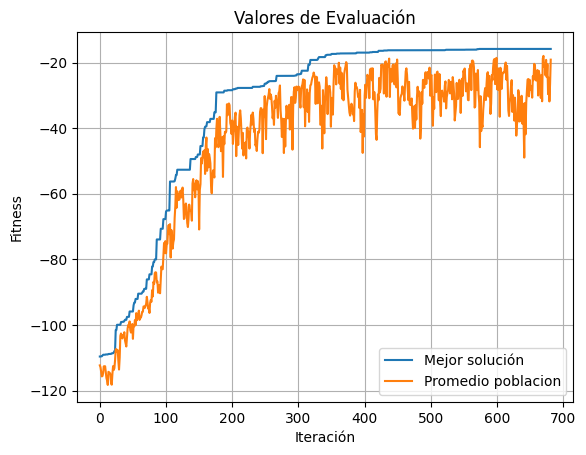

El schedule de solucion es [6.53202527004497, 0.0, 2.193505185487447, 3.406271806691525, 3.8969444242385247, 4.8835766048406395, 0.9497291839691461, 7.11492742307875, 7.669311614177674, 2.812456543691916, 9.955786384654466, 4.418828076010345, 10.597796664277906, 8.975884609959882, 9.493697639848152, 8.262411083771115, 6.0327902402922735, 0.4680572418853804, 1.5568780798186577, 5.464148278119129]
Promedio: 1.1483225281319056
VTotal extendida: [0, 0.3599999999999999, 0.64, 0.84, 0.96, 1.123689673274602, 1.4181354667829063, 1.5525812602912106, 1.527027053799515, 1.3414728473078192, 1.1868932851619074, 1.4411224258455286, 1.5353515665291497, 1.4695807072127707, 1.2438098478963924, 0.9898913802223681, 1.0747244081225502, 1.240010219152793, 1.245296030183036, 1.0905818412132793, 0.9870595361445696, 0.9925619999994957, 0.9438749914424237, 1.144181603687307, 1.184488215932191, 1.064794828177075, 0.9650271211478324, 0.9998312695377901, 0.9546354179277481, 1.14895796458058, 1.2337273479240705, 1

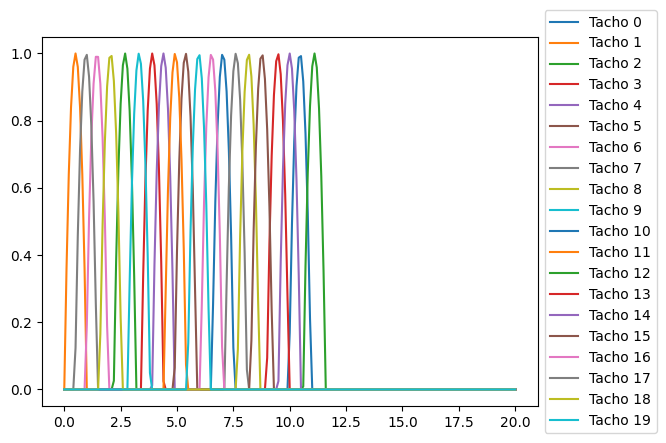

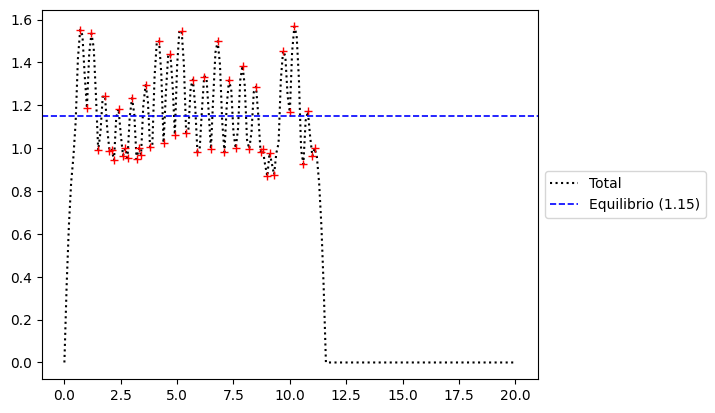

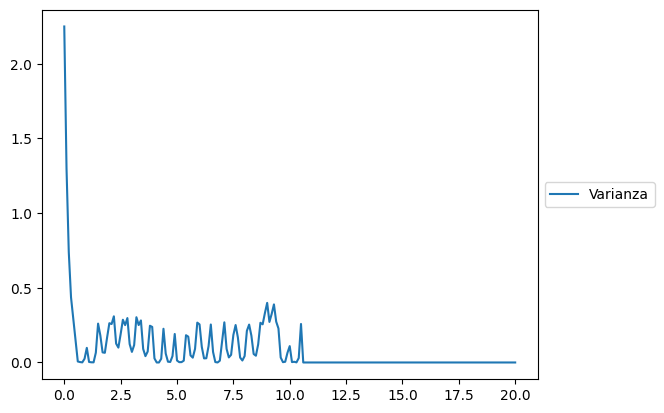

In [27]:
import random
import math

tachos = 20
intervalo = [x/10 for x in range(tachos*10+1)]
Bounds = [[0, tachos-1] for i in range(tachos)]

Enteras = [False] * (tachos)
f = Fitness
cant_individuos = 12
cant_generac = 75
cant_elite = 1
sel = sel_ruleta
eps = 0.1
xover = xov_cube
cant_cruzados = round(0.66 * cant_individuos)
mut = mut_step
cant_mutados = round(0.33 * cant_individuos)
callback = None
Variabilidad_weight = 14
Picos_weight = 0.06
DistMax_weight = 4
Pop = init_pop(cant_individuos, tachos, Bounds)

sol, solF, Pop, Fit, traceBest, traceAvg, bestSols = \
    geneticoTachos(Pop, cant_generac, Bounds, Enteras, sel, xover, mut, \
        cant_cruzados, cant_mutados, cant_elite, eps, f, Variabilidad_weight, \
        Picos_weight, DistMax_weight, tachos,intervalo, callback)

graficarEvolucionFitness(traceBest, traceAvg)
print(f'El schedule de solucion es {sol}')
print(f'El fitness de la solucion es {Fitness(sol, Variabilidad_weight, Picos_weight, DistMax_weight, intervalo, True)}')
graficarResultadosTachos(sol, tachos, intervalo)

# **Constancia**

El schedule de solucion es [5.330528919059055, 0.5264398708719763, 1.066350162016563, 2.5052822318761843, 3.1064961488703036, 4.816158737583985, 4.258342712825454, 5.836287862155736, 3.7430652750085316, 9.18836285438847, 9.69973021469663, 8.16347973396248, 1.5591236191684552, 8.641147513486873, 0.0, 6.8019103012137005, 7.733639500376215, 6.251394574905599, 2.040721706515947, 7.253026856716798]


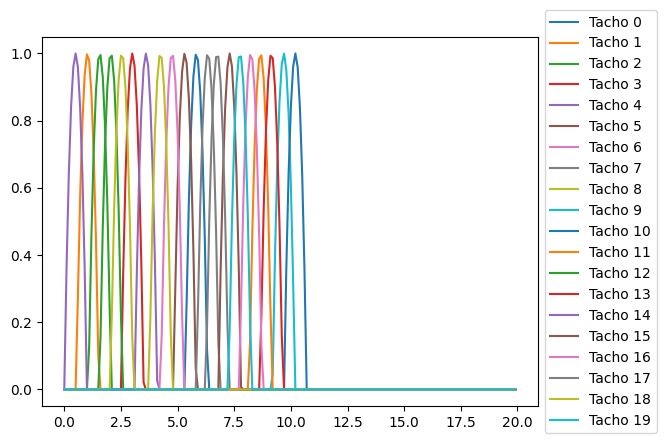

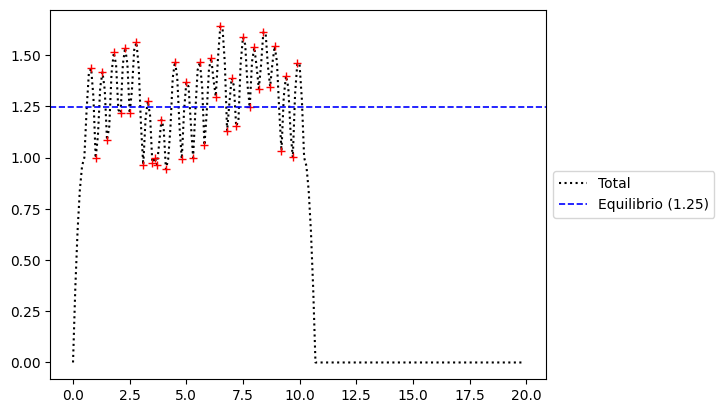

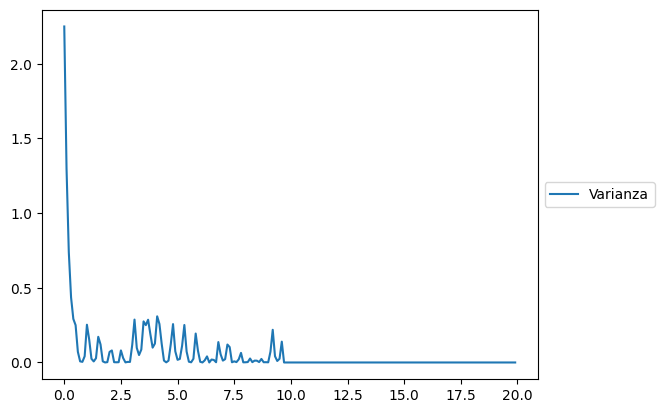

El schedule de solucion es [1.0614465630088561e-11, 0.5443499864158654, 1.5815749210547747, 2.9757678748908316, 4.313628446364706, 4.8333162040237845, 2.0900005445111263, 7.366166646051443, 7.854594463589572, 9.2970670325571, 2.562169055333838, 1.0671631520980482, 5.879650344249073, 6.847727444925572, 6.383093542695265, 3.82613626811229, 8.720631379075009, 8.33169716655959, 3.4154146920503305, 5.345565151887277]


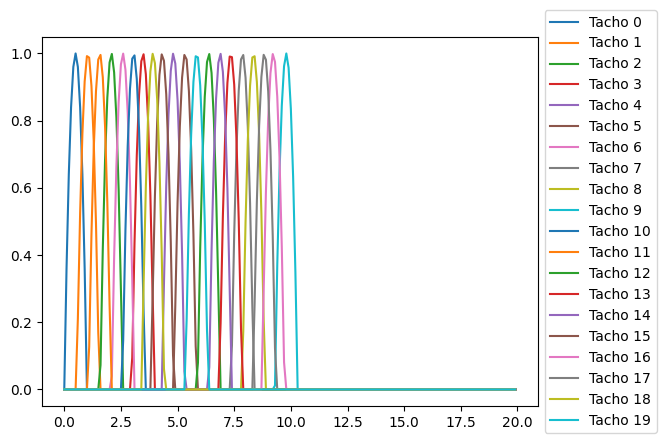

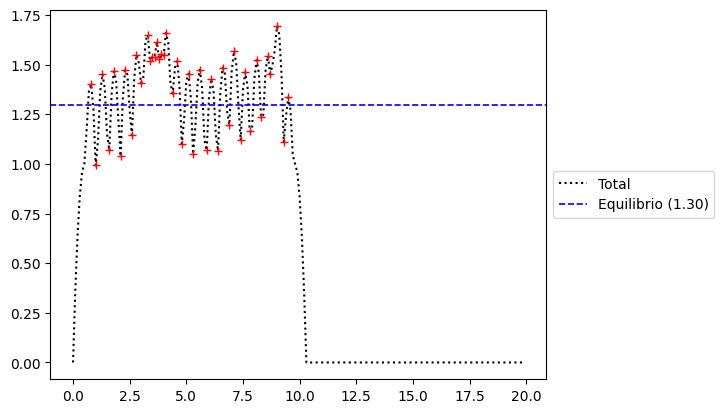

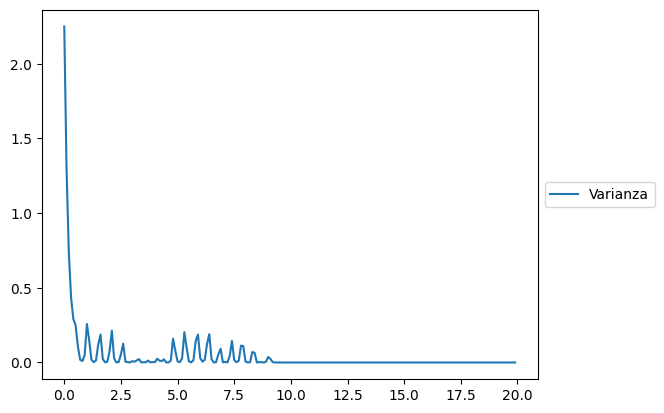

El schedule de solucion es [0.0, 0.4605462501122302, 1.8068366105931715, 2.840930630863868, 3.3870974405697116, 5.42592383059707, 5.838820785414025, 6.798345586953268, 7.641799367401768, 6.329076284347398, 4.496765408633674, 1.315960883665121, 7.256244337811247, 4.9981606160918535, 8.922472026466544, 8.108665342370903, 0.8679582632623546, 8.518491061131037, 2.356934164464605, 3.9642808807870513]


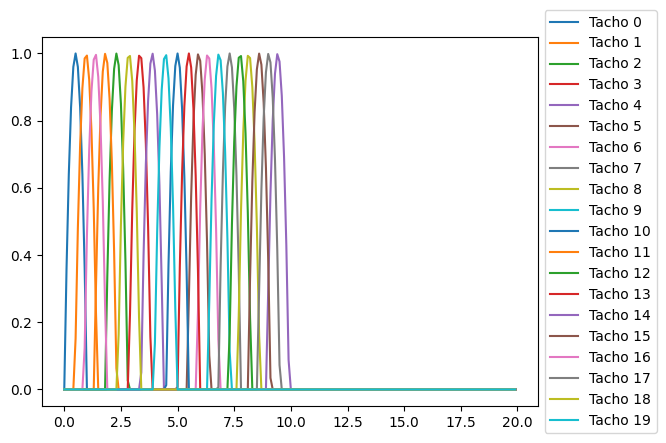

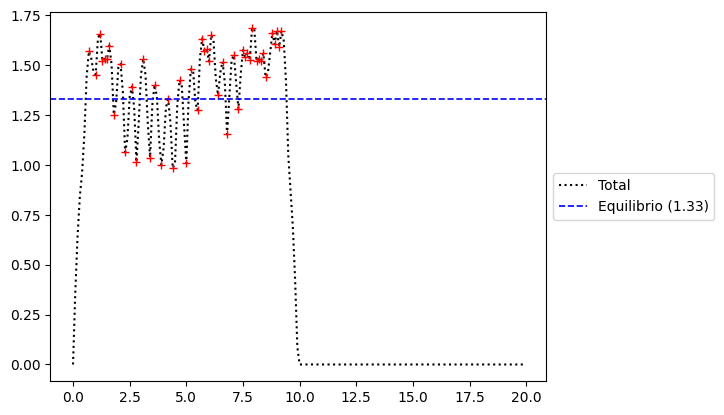

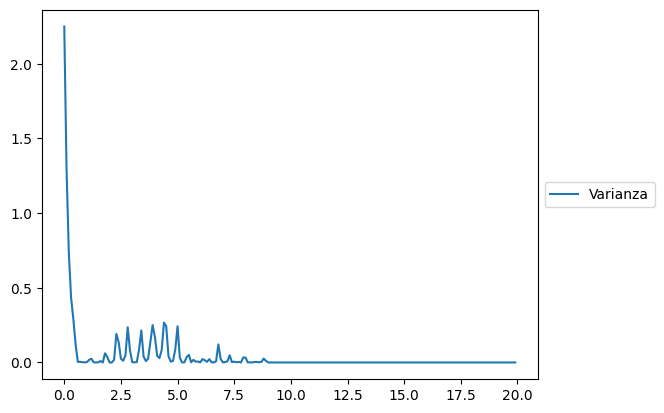

El schedule de solucion es [0.0, 0.43571362907527067, 1.9018035322846534, 2.7068803722883406, 4.071654270758114, 5.051487082233384, 3.0955708271561075, 6.465542224459071, 7.906013262334524, 8.73439621242646, 2.266902242589554, 8.298486636036438, 4.60857819543867, 0.9311925631719822, 5.526684626827545, 7.471908698138268, 3.5977515148047647, 6.0402384547478505, 1.3501474999068155, 6.963396569570173]


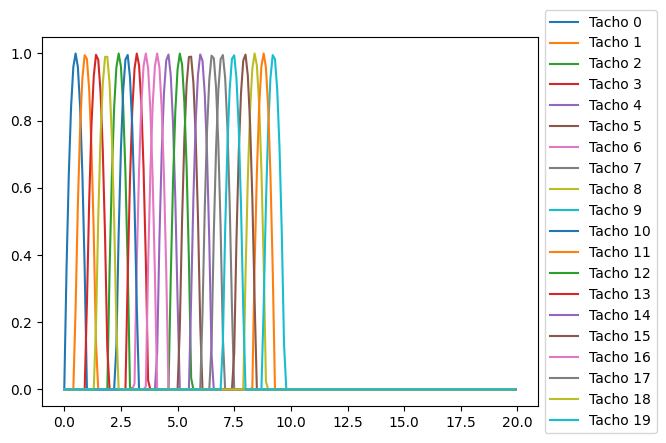

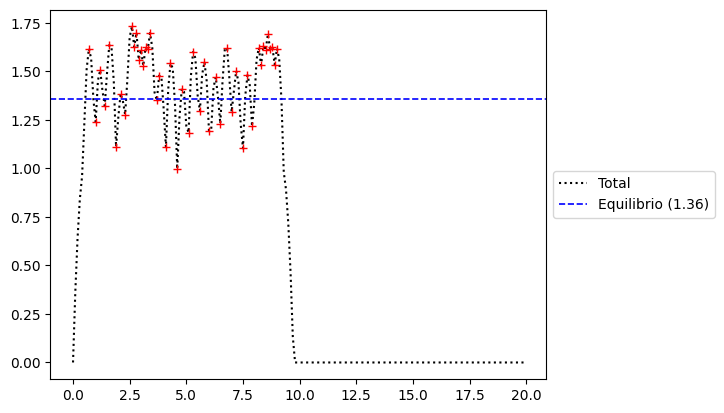

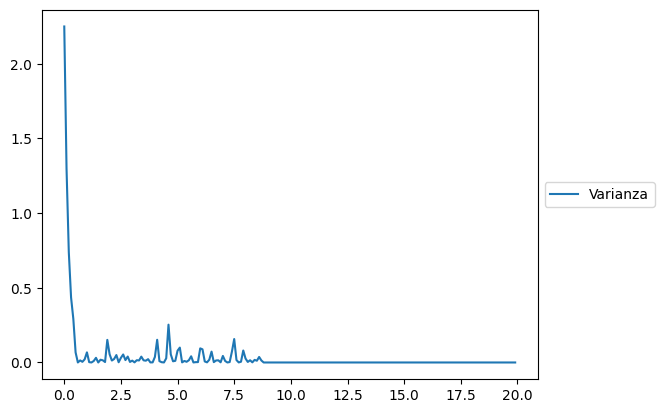

El schedule de solucion es [0.0, 0.9487612114005626, 3.73780046134085, 2.3502747972304916, 4.226326213756521, 5.187334353881787, 6.04275917732893, 1.913717954168141, 8.435583887797701, 7.584269493459631, 9.074654827013127, 1.419744609135939, 0.45552534171247305, 3.259493224173298, 8.037686915870202, 6.5677984549220705, 5.645860770410884, 2.750259741889175, 4.667213837914883, 7.052678135765842]


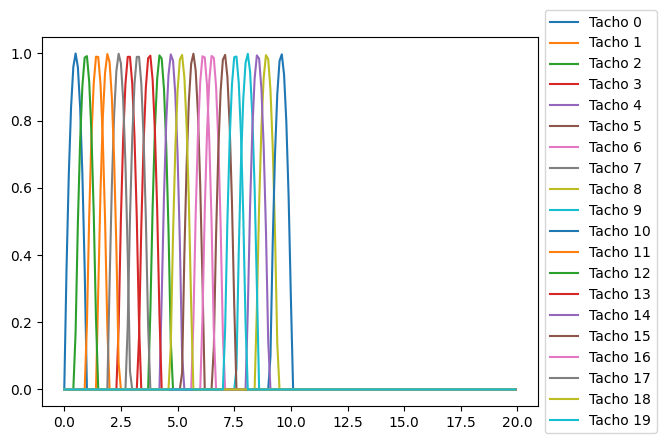

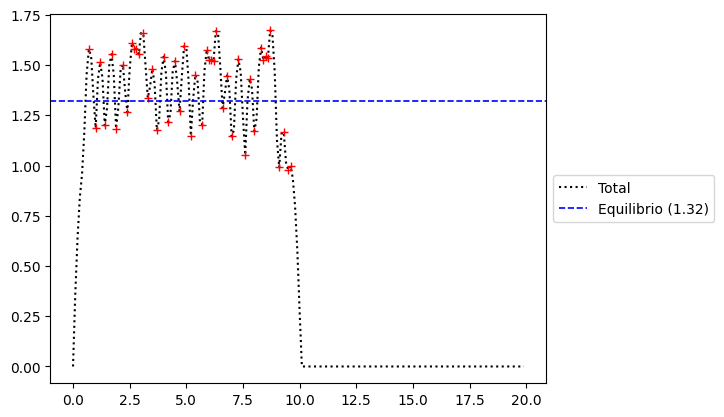

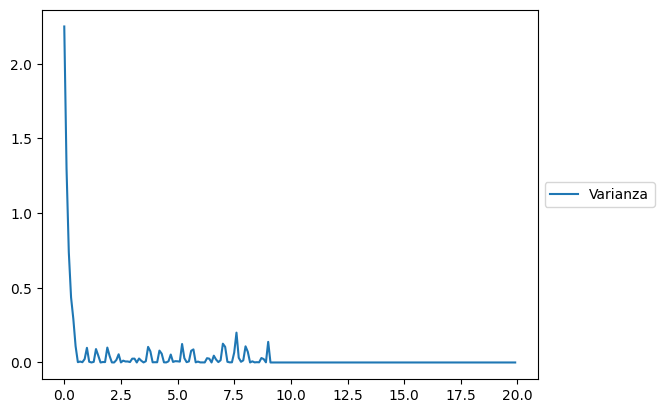

El schedule de solucion es [0.0, 0.4473958752764493, 1.946508149605602, 3.0369012816159233, 4.045540399599576, 8.2998027151373, 5.496466040709741, 6.938207339525768, 3.5410526977558145, 8.766765616913428, 9.394691752327757, 0.9219096478157284, 7.875778562119461, 2.4662700733728053, 6.445490052654659, 1.3845263386638318, 5.9450702504652835, 5.011884839084191, 7.450352370651241, 4.548694062906939]


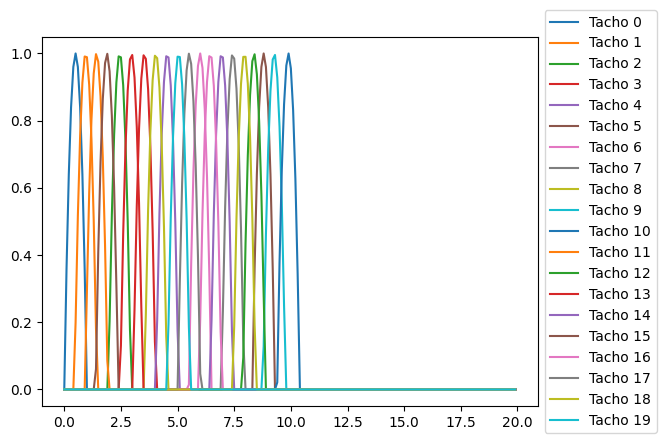

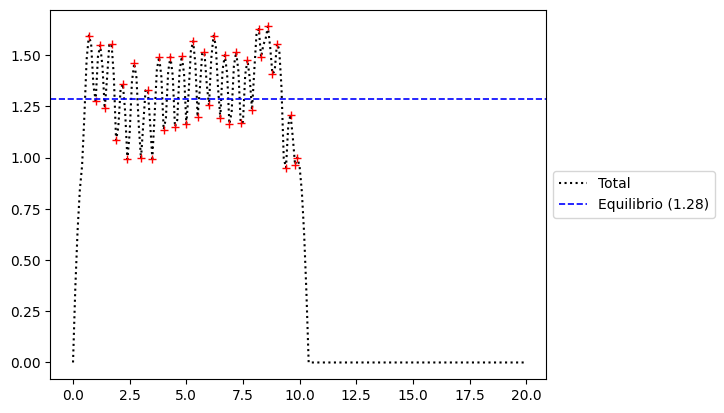

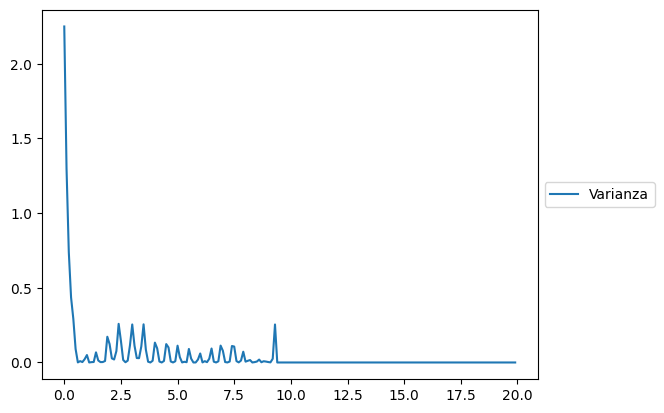

El schedule de solucion es [0.0, 0.6940876816550681, 1.5190054270617452, 3.024309842827198, 4.0638416852465715, 4.982907351136585, 5.428003092142128, 7.320612855760298, 7.782725546924762, 8.617895420546994, 4.526421485839665, 2.035465549498679, 8.253206386047045, 6.360213819729887, 5.880913295583501, 6.85968706674157, 0.0, 1.0415399974948452, 2.524105733943933, 3.583713084059285]


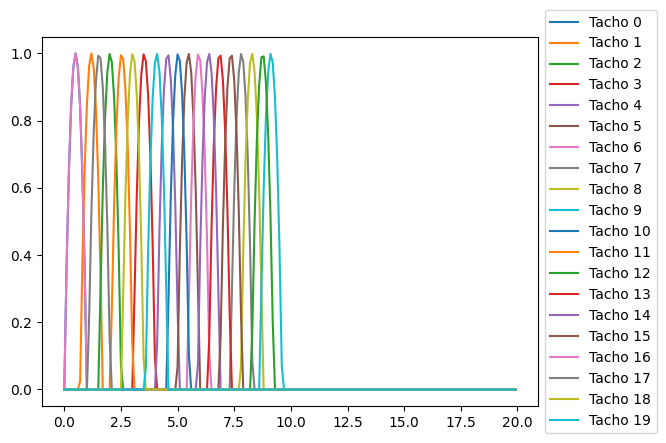

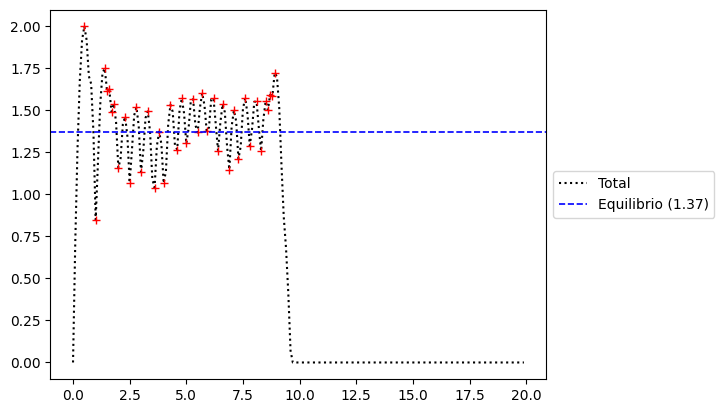

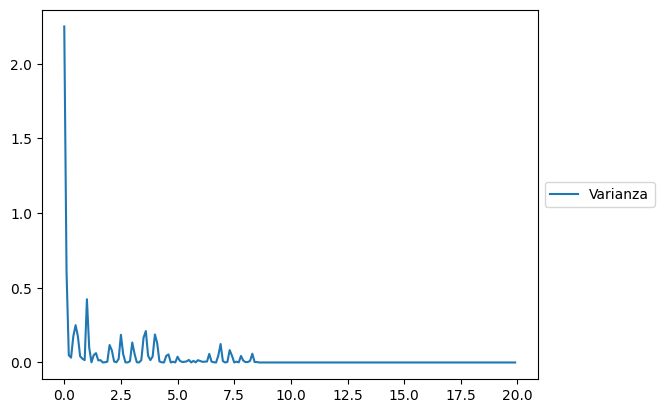

El schedule de solucion es [0.0, 1.6509634458541798, 2.1446390876125156, 2.660910325276138, 4.17096199358343, 4.666495710918792, 1.136678904210001, 7.140619055682371, 7.618714187059429, 8.538313594683327, 3.1766805965956153, 6.652186681304114, 8.075898246496541, 8.996197933862561, 6.164017844678516, 3.6553120083300694, 5.6599144045325644, 5.170747256434754, 0.6044736222632431, 9.582602538012042]


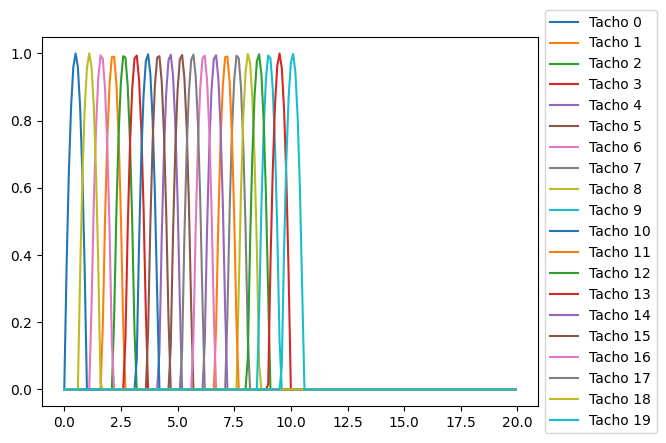

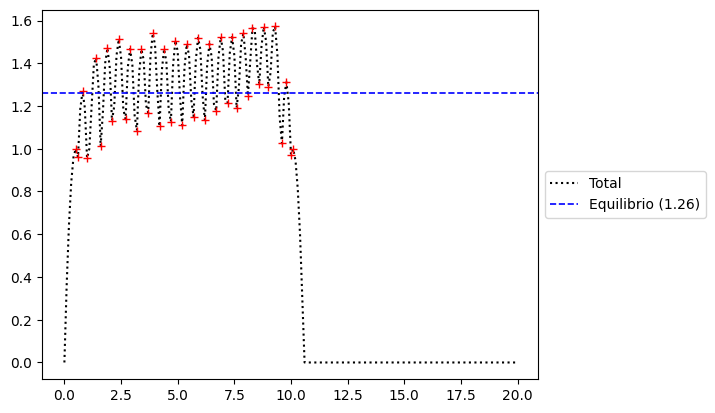

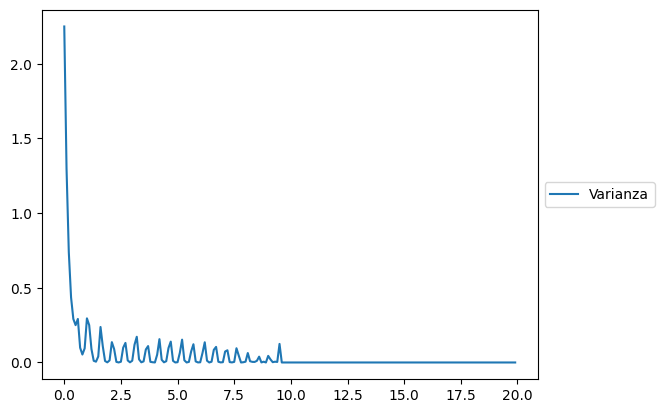

El schedule de solucion es [0.0, 0.610300505648096, 1.8352441146491076, 2.41558619279326, 3.9200383799022913, 6.55915590878856, 6.035060776155419, 5.475106198961109, 3.4231772304753854, 8.824965288536292, 2.934239790776123, 9.827789624954052, 7.137027085521776, 8.264371282873222, 10.352628617410401, 4.409947932127645, 4.935619472385284, 9.320920158714289, 1.2172278506163217, 7.665356201941261]


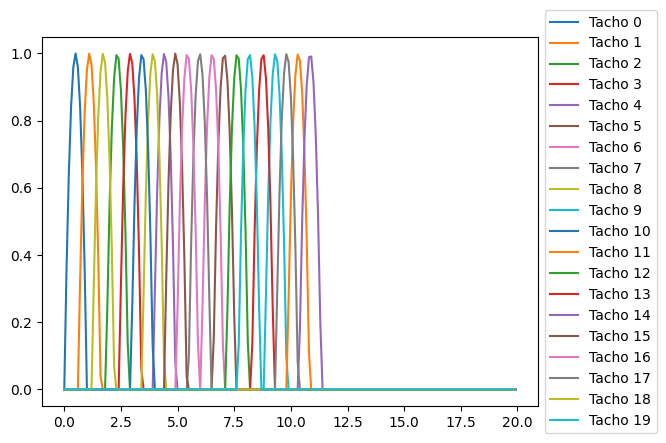

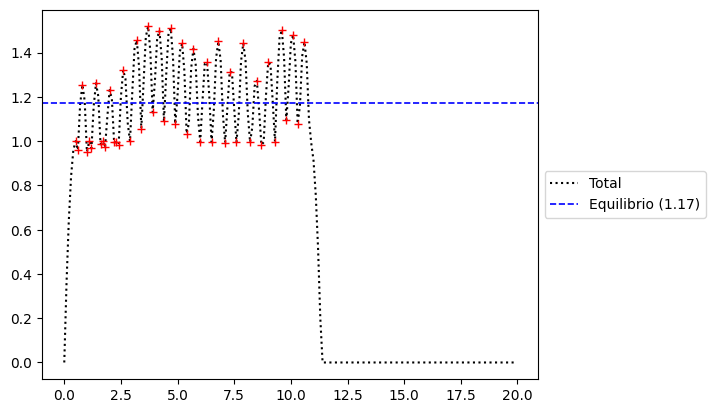

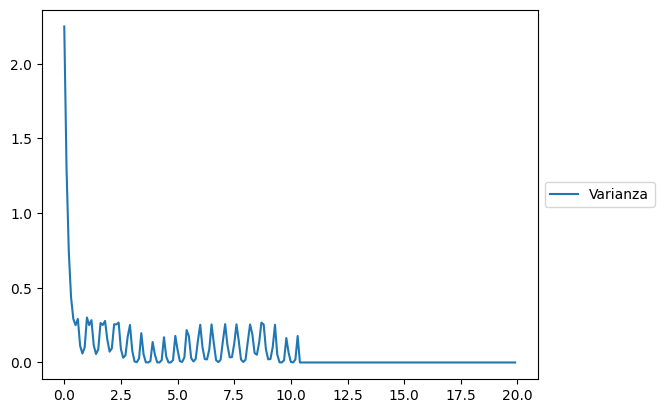

El schedule de solucion es [0.0, 0.4607758180423157, 1.9397001968502532, 1.4101574432824935, 4.5, 4.991157274026317, 6.6949870086252075, 3.9250168762856554, 7.967721412833999, 0.9351116253766063, 8.995940197221486, 5.400539383207666, 2.9300997598624954, 8.35374702708401, 3.37673003038434, 5.8300653693400495, 2.4141694876911757, 7.524851492053252, 7.082677913332204, 6.262951377300674]


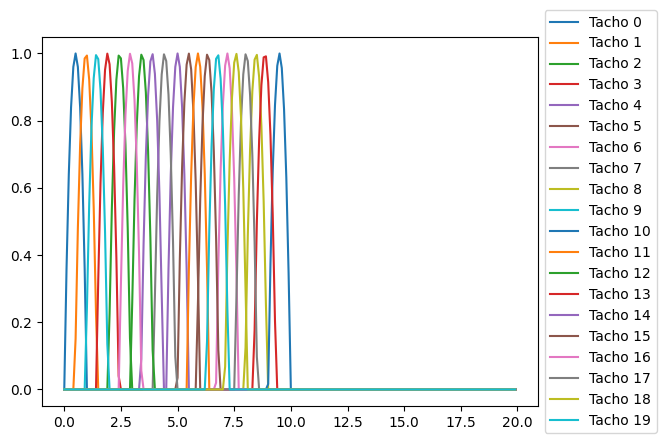

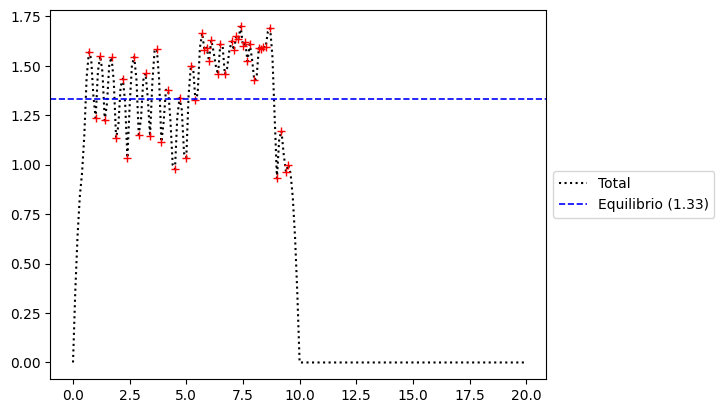

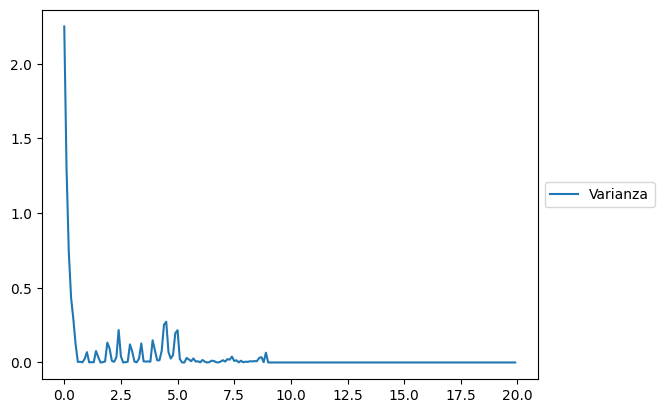

In [ ]:
tachos = 20
intervalo = [x/10 for x in range(tachos*10 + 1)] # sumar 1 para que llegue a 200 en caso de 20 tachos por ejc
Bounds = [[0, tachos-1] for i in range(tachos)]

Enteras = [False] * (tachos)
f = Fitness
cant_individuos = 12
cant_generac = 75
cant_elite = 1
sel = sel_ruleta
eps = 0.1
xover = xov_cube
cant_cruzados = round(0.66 * cant_individuos)
mut = mut_step
cant_mutados = round(0.33 * cant_individuos)
callback = None
Variabilidad_weight = 14
Picos_weight = 0.06
DistMax_weight = 4

for i in range(10):
    Pop = init_pop(cant_individuos, tachos, Bounds)
    sol, solF, Pop, Fit, traceBest, traceAvg, bestSols = \
        geneticoTachos(Pop, cant_generac, Bounds, Enteras, sel, xover, mut, \
            cant_cruzados, cant_mutados, cant_elite, eps, f, Variabilidad_weight, \
            Picos_weight, DistMax_weight, tachos,intervalo, callback)

    print(f'El schedule de solucion es {sol}')
    graficarResultadosTachos(sol, tachos, intervalo)

# **Interpretación**

Consideramos este algoritmo bastante bueno por algunos motivos

1.   La variacion que tiene es entre 1.00 y 1.60 aproximadamente, con un promedio de la curva en 1.32. Esto nos da una variacion de 45%, comparado al 22% que consideramos del ideal, lo vemos con buenos ojos
2.   Mejora la solucion trivialde que cada tacho comience al terminar el anterior, desde el punto de vista del tiempo
3.   La curva sigue, respetando las distancias, una suerte de curva parecida a la que consideramos como ideal
4. También mejora la solución trivial de que todos los tachos arranquen al mismo tiempo, y evita sobrepicos excesivos.
5. Logra reducir el tiempo total de consumo de los tachos a la mitad, en la mayoría de las ejecuciones, del caso trivial de los tachos arrancando uno atrás del otro.


# **Conclusiones**

Al momento de buscar la solución óptima, notamos que este problema podríamos minimzarlo a buscar el tiempo de separacion de cada tacho. De esta forma, la funcion se haría lo mas constante posible, el tiempo tambíen tendería a bajar. También de esta forma el problema pasaría a ser deterministico, o al menos solo tendría una variable, que además tendria un valor minimo y un valor máximo.

A esta conclusión llegamos desde el entorno acotado de este problema, entendemos que en una situacion real deben haber mas limitaciones que no permitan esta solución.